# 🔭 OGLE-IV Parameter Evaluation

This notebook analyzes the empirical distributions of microlensing parameters from the **OGLE-IV Galactic Bulge survey**.

---

In [1]:
import os
import sys
from pathlib import Path
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

def setup_environment():
    if 'google.colab' in sys.modules:
        from google.colab import drive
        drive.mount('/content/drive')
        PROJECT_ROOT = Path('/content/drive/MyDrive/Microlensing_project')
        os.chdir(PROJECT_ROOT)
    else:
        current = Path(os.getcwd())
        while current != current.parent:
            if (current / 'src').exists():
                PROJECT_ROOT = current
                break
            current = current.parent
        else:
            PROJECT_ROOT = Path(os.getcwd())
    
    if str(PROJECT_ROOT) not in sys.path:
        sys.path.append(str(PROJECT_ROOT))
    return PROJECT_ROOT

ROOT = setup_environment()
from src.utils.data_parsing import parse_ogle_iv_table

## 1. Download and Load Data

In [2]:
URL = "https://www.astrouw.edu.pl/ogle/ogle4/microlensing_maps/table3.dat"
DATA_DIR = ROOT / "data" / "ogleiv"
FILE_PATH = DATA_DIR / "table3.dat"
SAVE_PATH = DATA_DIR / "ogle_parameters.parquet"

DATA_DIR.mkdir(parents=True, exist_ok=True)

if not FILE_PATH.exists():
    print(f"Downloading data from {URL}...")
    response = requests.get(URL)
    with open(FILE_PATH, 'wb') as f:
        f.write(response.content)
    print("Download complete.")
else:
    print("Data already exists locally.")

df = parse_ogle_iv_table(str(FILE_PATH))

# Using 'fastparquet' engine to avoid ArrowKeyError in some Python environments
try:
    df.to_parquet(SAVE_PATH, engine='fastparquet', index=False)
    print(f"Parsed {len(df)} events. Saved via fastparquet to {SAVE_PATH}")
except Exception as e:
    print(f"Parquet error: {e}. Falling back to CSV for local compatibility.")
    CSV_PATH = SAVE_PATH.with_suffix('.csv')
    df.to_csv(CSV_PATH, index=False)
    print(f"Saved to {CSV_PATH}")

df.head()

Data already exists locally.
Parsed 5790 events. Saved via fastparquet to c:\Users\jrosel3\Desktop\Microlensing\Microlensing_project\data\ogleiv\ogle_parameters.parquet


,name,field,star_id,ra_h,ra_m,ra_s,dec_d,dec_m,dec_s,ra,...,u0_err1,u0_err2,Is_med,Is_err1,Is_err2,fs_med,fs_err1,fs_err2,weight,ews_id
0,BLG617.16.73378,BLG617.16,73378,17,13,8.00,-29,48,13.0,258.28333,...,-0.045,0.041,20.105,-0.234,0.308,0.910,-0.224,.219,4.10,X
1,BLG617.24.41328,BLG617.24,41328,17,13,54.30,-29,36,35.5,258.47625,...,-0.016,0.019,20.286,-0.156,0.144,0.248,-0.031,.038,2.80,OGLE-2016-BLG-0231
2,BLG616.32.9872,BLG616.32,9872,17,13,56.45,-28,8,40.8,258.48521,...,-0.007,0.010,20.859,-0.404,0.441,0.872,-0.288,.388,8.58,X
3,BLG617.24.47717,BLG617.24,47717,17,13,56.92,-29,32,34.2,258.48717,...,-0.052,0.048,20.344,-0.251,0.342,1.073,-0.289,.278,4.64,OGLE-2016-BLG-1459
4,BLG617.07.43804,BLG617.07,43804,17,14,0.26,-30,8,42.2,258.50108,...,-0.317,0.336,19.742,-0.826,1.011,0.360,-0.218,.410,3.61,OGLE-2017-BLG-0395


## 2. Einstein Timescale ($t_E$) Analysis

Median tE: 25.75 days


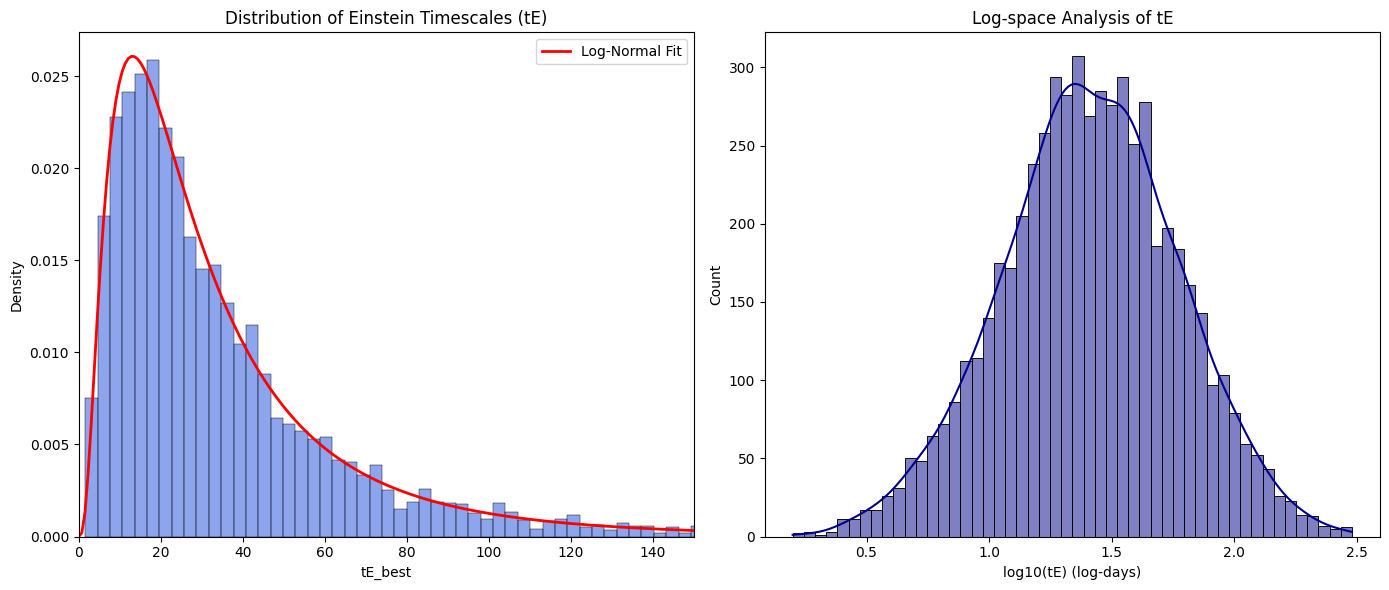

In [3]:
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.histplot(df['tE_best'], bins=100, kde=False, color='royalblue', stat="density", alpha=0.6)
x = np.linspace(0, 150, 200)
shape, loc, scale = stats.lognorm.fit(df['tE_best'])
pdf = stats.lognorm.pdf(x, shape, loc, scale)
plt.plot(x, pdf, 'r-', lw=2, label='Log-Normal Fit')
plt.xlim(0, 150)
plt.title("Distribution of Einstein Timescales (tE)")
plt.legend()

plt.subplot(1, 2, 2)
log_te = np.log10(df['tE_best'])
sns.histplot(log_te, bins=50, kde=True, color='darkblue')
plt.title("Log-space Analysis of tE")
plt.xlabel("log10(tE) (log-days)")

median_te = df['tE_best'].median()
print(f"Median tE: {median_te:.2f} days")
plt.tight_layout()
plt.show()

## 3. Impact Parameter ($u_0$) Analysis & Beta Distribution

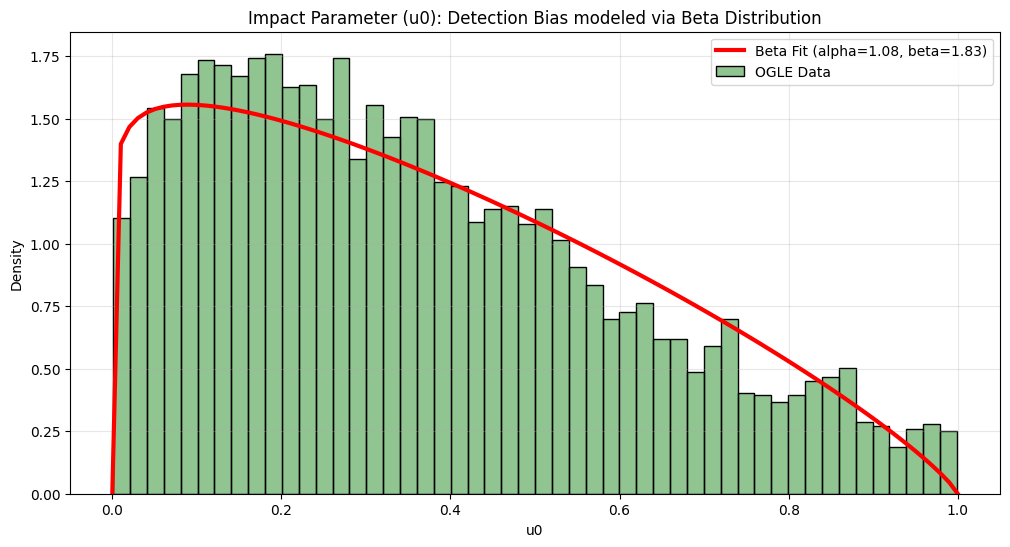

Best Fit Alpha: 1.0806
Best Fit Beta: 1.8276


In [4]:
plt.figure(figsize=(12, 6))
u0_data = df[(df['u0_best'] > 0) & (df['u0_best'] < 1.0)]['u0_best']
eps = 1e-6
u0_data_clean = np.clip(u0_data, eps, 1 - eps)
a_fit, b_fit, loc_fit, scale_fit = stats.beta.fit(u0_data_clean, floc=0, fscale=1)

sns.histplot(u0_data_clean, bins=50, color='forestgreen', alpha=0.5, stat="density", label='OGLE Data')
x = np.linspace(0, 1, 100)
plt.plot(x, stats.beta.pdf(x, a_fit, b_fit, loc_fit, scale_fit), 'r-', lw=3, label=f'Beta Fit (alpha={a_fit:.2f}, beta={b_fit:.2f})')
plt.title("Impact Parameter (u0): Detection Bias modeled via Beta Distribution")
plt.xlabel("u0")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
print(f"Best Fit Alpha: {a_fit:.4f}")
print(f"Best Fit Beta: {b_fit:.4f}")

## 4. Blending Fraction ($f_s$) Analysis

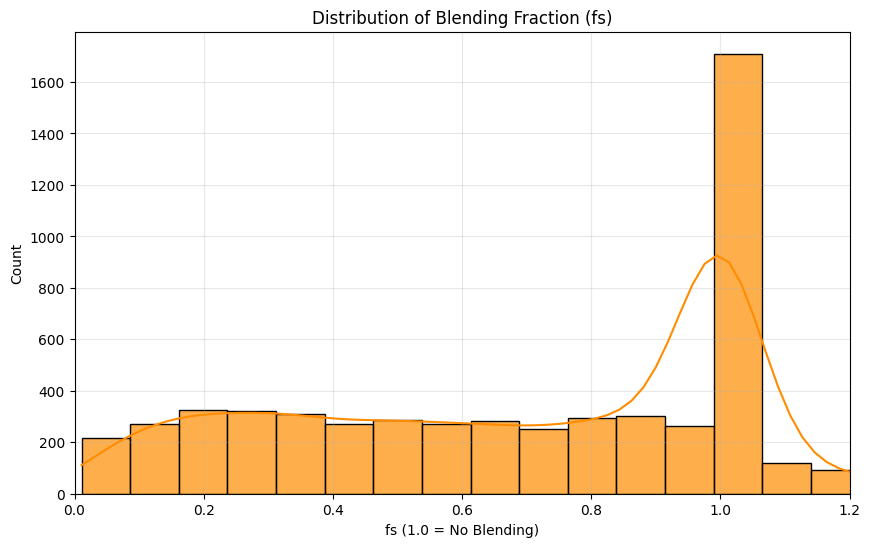

In [5]:
plt.figure(figsize=(10, 6))
sns.histplot(df['fs_best'], bins=50, color='darkorange', alpha=0.7, kde=True)
plt.title("Distribution of Blending Fraction (fs)")
plt.xlabel("fs (1.0 = No Blending)")
plt.xlim(0, 1.2)
plt.grid(alpha=0.3)
plt.show()

## 5. Summary and Prior Anchoring

Based on the OGLE-IV data, we should update our simulation with these parameters to make our training set 'Galactic':

In [6]:
print("--- Final Suggested Simulated Priors ---")
print(f"1. tE: Log-Normal fit with shape={shape:.2f} and scale={scale:.2f}")
print(f"2. u0 (Physical): Uniform(0, 1.0)")
print(f"3. u0 (Detection Biased): Beta(a={a_fit:.2f}, b={b_fit:.2f})")
print(f"4. fs: Sample from the observed multimodal distribution")

--- Final Suggested Simulated Priors ---
1. tE: Log-Normal fit with shape=0.82 and scale=26.14
2. u0 (Physical): Uniform(0, 1.0)
3. u0 (Detection Biased): Beta(a=1.08, b=1.83)
4. fs: Sample from the observed multimodal distribution
